<a href="https://colab.research.google.com/github/braswellcolin/mane4961/blob/main/hw3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1


In [2]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv('aircraft_performance.csv')

Saving aircraft_performance.csv to aircraft_performance (1).csv


k = 2 Silhouette score = 0.6404033542802476
k = 3 Silhouette score = 0.6897697333231053
k = 4 Silhouette score = 0.7945390957110717
k = 5 Silhouette score = 0.7290916642346795
k = 6 Silhouette score = 0.6566428819649092


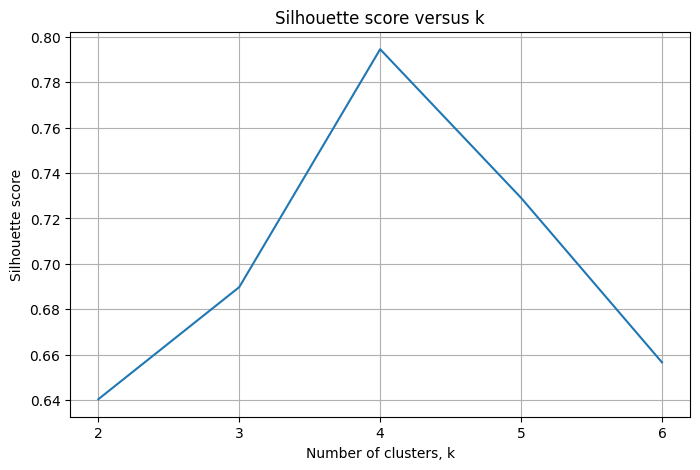

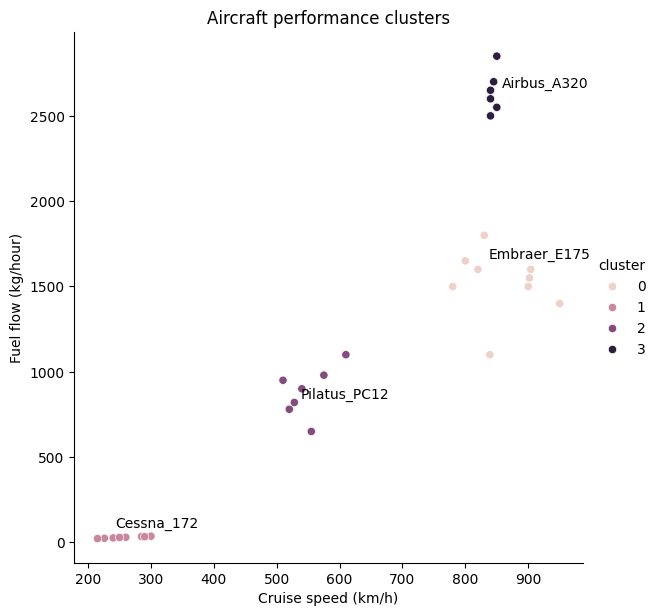

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

X = df[['Speed_kmh', 'FuelFlow_kgph']].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

silhouette_scores = []

for k in range(2, 7):
    model = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=123
    )

    model.fit(X_scaled)

    score = silhouette_score(X_scaled, model.labels_)
    silhouette_scores.append(score)

    print('k =', k, 'Silhouette score =', score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 7), silhouette_scores)
plt.xticks(range(2, 7))
plt.xlabel('Number of clusters, k')
plt.ylabel('Silhouette score')
plt.title('Silhouette score versus k')
plt.grid(True)
plt.show()

k = 4

model = KMeans(
    n_clusters=k,
    init='k-means++',
    n_init='auto',
    random_state=123
)

model.fit(X_scaled)
df['cluster'] = model.labels_

sns.pairplot(
    df,
    x_vars=['Speed_kmh'],
    y_vars=['FuelFlow_kgph'],
    hue='cluster',
    height=6
)

representatives = [
    'Cessna_172',
    'Pilatus_PC12',
    'Embraer_E175',
    'Airbus_A320'
]

for name in representatives:
    aircraft = df[df['Aircraft'] == name].iloc[0]

    plt.annotate(
        name,
        (aircraft['Speed_kmh'], aircraft['FuelFlow_kgph']),
        xytext=(8, 8),
        textcoords='offset points'
    )

plt.xlabel('Cruise speed (km/h)')
plt.ylabel('Fuel flow (kg/hour)')
plt.title('Aircraft performance clusters')
plt.show()

In [ ]:
Q2

In [6]:
from google.colab import files

uploaded = files.upload()

Saving housing_prices.txt to housing_prices.txt


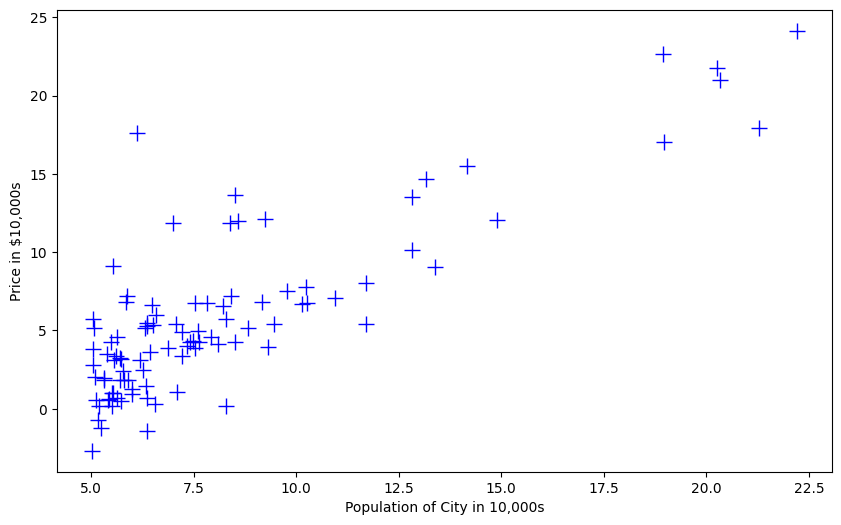

In [7]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d, Axes3D
from matplotlib import cm
import itertools

datafile = 'housing_prices.txt'
cols = np.loadtxt(datafile,delimiter=',',usecols=(0,1),unpack=True)
X = np.transpose(np.array(cols[:-1]))
y = np.transpose(np.array(cols[-1:]))
m = y.size
X = np.insert(X,0,1,axis=1)

plt.figure(figsize=(10,6))
plt.plot(X[:,1],y[:,0],'b+',markersize=12)
plt.xlabel('Population of City in 10,000s')
plt.ylabel('Price in $10,000s')
plt.show()

/tmp/ipykernel_2090/974531165.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float((1./(2*m)) * np.dot((h(w,X)-y).T,(h(w,X)-y)))


Batch size: 1 Predicted price ($): 147181.00499529968
Batch size: 5 Predicted price ($): 169463.73724360942
Batch size: 10 Predicted price ($): 171657.32921861854
Batch size: 20 Predicted price ($): 145909.32809464587


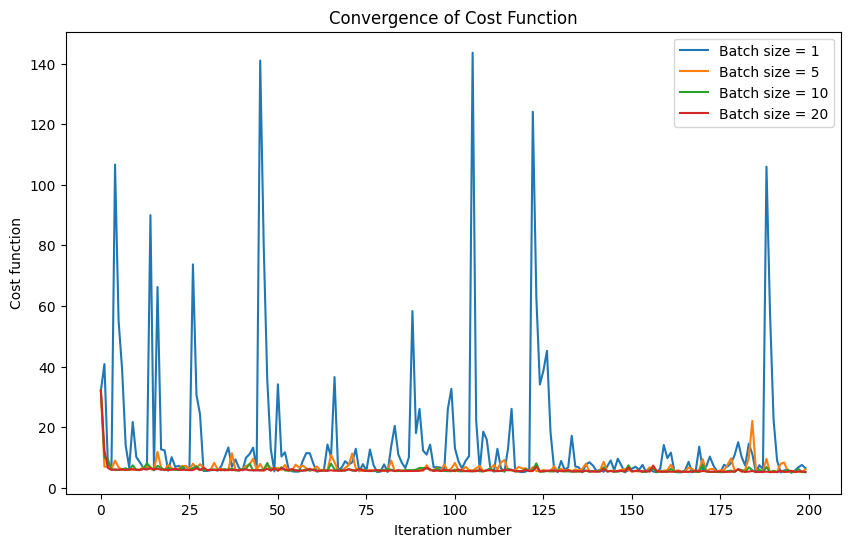

In [14]:
def h(w,X):
    return np.dot(X,w)


def mse(w,X,y):
    return float((1./(2*m)) * np.dot((h(w,X)-y).T,(h(w,X)-y)))


def gradient_descend(X, w_start=np.zeros(2), batch_size=1):
    w = w_start
    J_values = []
    w_store = []

    for _ in range(iterations):
        temp_w = w
        J_values.append(mse(w,X,y))
        w_store.append(list(w[:,0]))

        #computes the gradients on small random sets of instances, mini batches
        indices = np.random.choice(m, batch_size, replace=False)
        X_batch = X[indices]
        y_batch = y[indices]

        for j in range(len(temp_w)):
            temp_w[j] = w[j] - (alpha/batch_size)*np.sum((h(w,X_batch) - y_batch)*np.array(X_batch[:,j]).reshape(batch_size,1))

        w = temp_w

    return w, w_store, J_values


def predict(xval):
    return w[0] + w[1]*xval


iterations = 200
alpha = 0.01

plt.figure(figsize=(10,6))

for batch_size in [1, 5, 10, 20]:
    np.random.seed(0)
    w_start = np.zeros((X.shape[1],1))

    w, w_store, J_values = gradient_descend(X,w_start,batch_size)

    plt.plot(
        range(len(J_values)),
        J_values,
        label='Batch size = ' + str(batch_size)
    )

    price = predict(16)[0] * 10000
    print('Batch size:', batch_size, 'Predicted price ($):', price)

plt.title("Convergence of Cost Function")
plt.xlabel("Iteration number")
plt.ylabel("Cost function")
plt.legend()
plt.show()

/tmp/ipykernel_2090/974531165.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float((1./(2*m)) * np.dot((h(w,X)-y).T,(h(w,X)-y)))


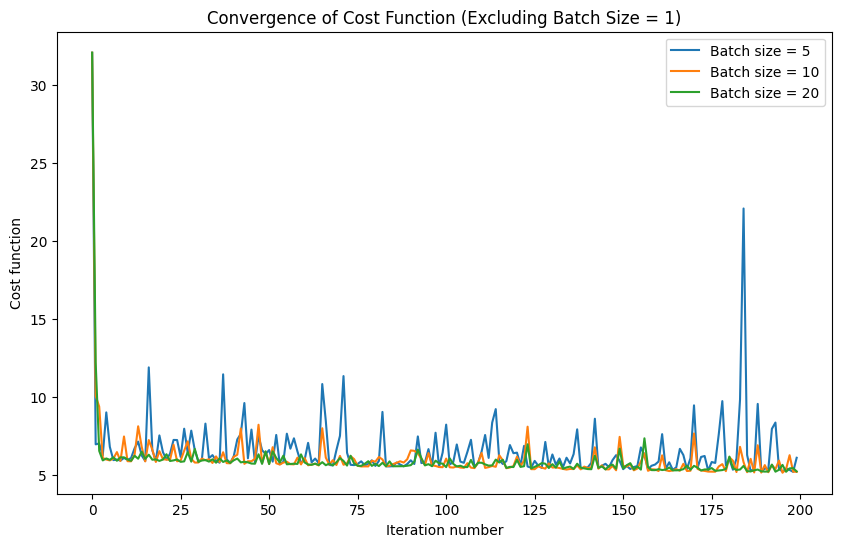

In [19]:
plt.figure(figsize=(10,6))

for batch_size in [5, 10, 20]:
    np.random.seed(0)
    w_start = np.zeros((X.shape[1],1))

    w, w_store, J_values = gradient_descend(X,w_start,batch_size)

    plt.plot(
        range(len(J_values)),
        J_values,
        label='Batch size = ' + str(batch_size)
    )


plt.title("Convergence of Cost Function (Excluding Batch Size = 1)")
plt.xlabel("Iteration number")
plt.ylabel("Cost function")
plt.legend()
plt.show()

Q3

The best features are : ['worst radius' 'worst concave points']
accuraccy score:  0.9473684210526315
              precision    recall  f1-score   support

   malignant       0.95      0.90      0.93        63
      benign       0.95      0.97      0.96       108

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



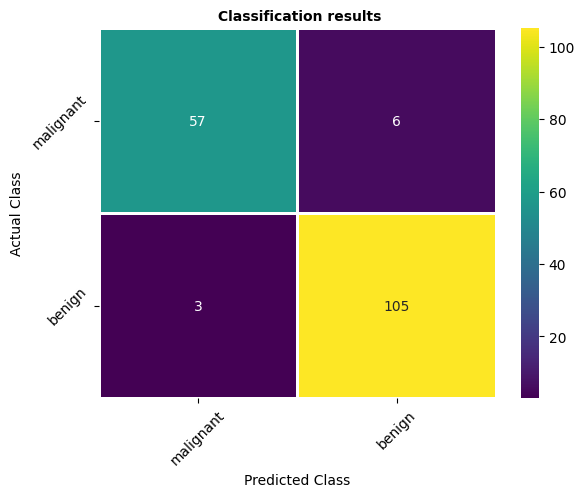

In [26]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

data = datasets.load_breast_cancer()
X = data["data"]
y = data["target"]

#print('original features and their names :', data.feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr = LogisticRegression(solver='lbfgs', max_iter=1000)
rfe = RFE(lr, n_features_to_select=2)
rfe = rfe.fit(X_train, y_train)

#print('True/False Selection of features:', rfe.support_)
print('The best features are :', np.array(data.feature_names)[rfe.support_])

preds = rfe.predict(X_test)

print("accuraccy score: ", accuracy_score(y_test, preds))
print(classification_report(y_test, preds, target_names=data.target_names))

cm = confusion_matrix(y_test, preds)
ax = sns.heatmap(cm, linewidths=2, annot=True, fmt='d', cmap='viridis', cbar=True)

ax.set_xticklabels(data.target_names)
ax.set_yticklabels(data.target_names)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.title(' Classification results', fontsize='medium', fontweight='bold')
plt.show()

Q4

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
R-squared: 0.6243847107377367
Predicted price ($): 124228.26


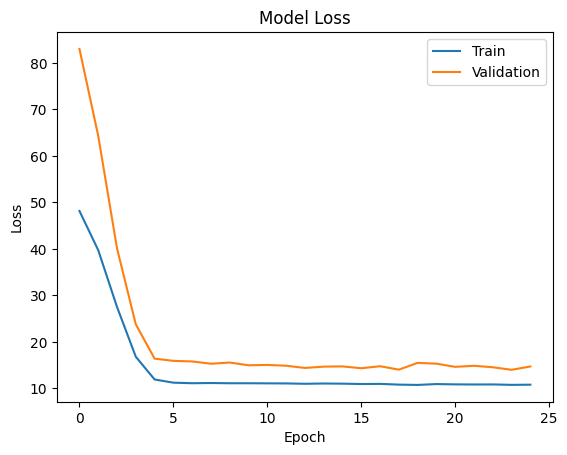

In [45]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers
from sklearn.model_selection import train_test_split

datafile = 'housing_prices.txt'
cols = np.loadtxt(datafile,delimiter=',',usecols=(0,1),unpack=True)
X = np.transpose(np.array(cols[:-1]))
y = np.transpose(np.array(cols[-1:]))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    train_size=0.70,
    random_state=123,
    shuffle=True
)

learning_rate = 0.00008
epochs = 25

model = Sequential()
model.add(Dense(2, input_dim=1, activation="relu"))
model.add(Dense(1))

opt = optimizers.SGD(learning_rate=learning_rate)
mse = tf.keras.losses.MeanSquaredError()
model.compile(loss=mse, optimizer=opt)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=1,
    verbose=0
)

predictions = model.predict(X_test)

r2 = 1 - np.sum((y_test - predictions) ** 2) / np.sum(
    (y_test - np.mean(y_test)) ** 2
)
print("R-squared:", r2)

X_new = np.array([[16.5]])
price = model.predict(X_new, verbose=0)[0, 0] * 10000
print("Predicted price ($):", price)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'], loc='upper right')
plt.show()